# Desafio TelecomX Latam - Parte 2

### Mervy Rita Mulatillo Piñin
### Grupo: 09

# Parte 1

##📌 Extracción

In [4]:
# ==============================================================================
# 1. IMPORTACIÓN DE BIBLIOTECAS
# ==============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
# ==============================================================================
# 2. EXTRACCIÓN Y CARGA DE DATOS (API JSON)
# ==============================================================================
print("--- Iniciando Extracción de Datos ---")
url = "https://raw.githubusercontent.com/alura-cursos/challenge2-data-science-LATAM/main/TelecomX_Data.json"

# Cargamos el JSON y lo "aplanamos" para que las columnas anidadas sean legibles
df_raw = pd.read_json(url)
df = pd.json_normalize(df_raw.to_dict('records'))

print(f"Dataset cargado con {df.shape[0]} filas y {df.shape[1]} columnas.")

--- Iniciando Extracción de Datos ---
Dataset cargado con 7267 filas y 21 columnas.


##🔧 Transformación

In [6]:
# ==============================================================================
# 3. LIMPIEZA Y TRATAMIENTO DE DATOS (ETL)
# ==============================================================================
# A. Corregir columna de cargos totales (contiene espacios vacíos " ")
df['account.Charges.Total'] = pd.to_numeric(df['account.Charges.Total'], errors='coerce')
# Los clientes con tenure 0 (nuevos) tienen NaN en Total, los llenamos con 0
df['account.Charges.Total'] = df['account.Charges.Total'].fillna(0)

# B. Verificar duplicados
duplicados = df.duplicated().sum()
print(f"Duplicados encontrados: {duplicados}")
df.drop_duplicates(inplace=True)

# C. Estandarización: Renombrar columnas al español para el informe
traduccion_columnas = {
    'Churn': 'Evasion',
    'customer.gender': 'Genero',
    'customer.SeniorCitizen': 'Adulto_Mayor',
    'customer.tenure': 'Meses_Contrato',
    'account.Contract': 'Tipo_Contrato',
    'account.PaymentMethod': 'Metodo_Pago',
    'account.Charges.Monthly': 'Cargo_Mensual',
    'account.Charges.Total': 'Cargo_Total'
}
df.rename(columns=traduccion_columnas, inplace=True)

# D. Transformación de datos: Convertir valores Yes/No a binarios (1/0)
# Esto facilita el cálculo de correlaciones y promedios de evasión
df['Evasion_Binaria'] = df['Evasion'].map({'Yes': 1, 'No': 0})

Duplicados encontrados: 0


##📊 Carga y análisis


--- Resumen Estadístico de Variables Numéricas ---


,Meses_Contrato,Cargo_Mensual,Cargo_Total,Cuentas_Diarias
count,7267.000000,7267.000000,7267.000000,7267.000000
mean,32.346498,64.720098,2277.182035,2.157292
std,24.571773,30.129572,2268.648587,1.004407
min,0.000000,18.250000,0.000000,0.610000
25%,9.000000,35.425000,396.200000,1.180000
50%,29.000000,70.300000,1389.200000,2.340000
75%,55.000000,89.875000,3778.525000,2.995000
max,72.000000,118.750000,8684.800000,3.960000


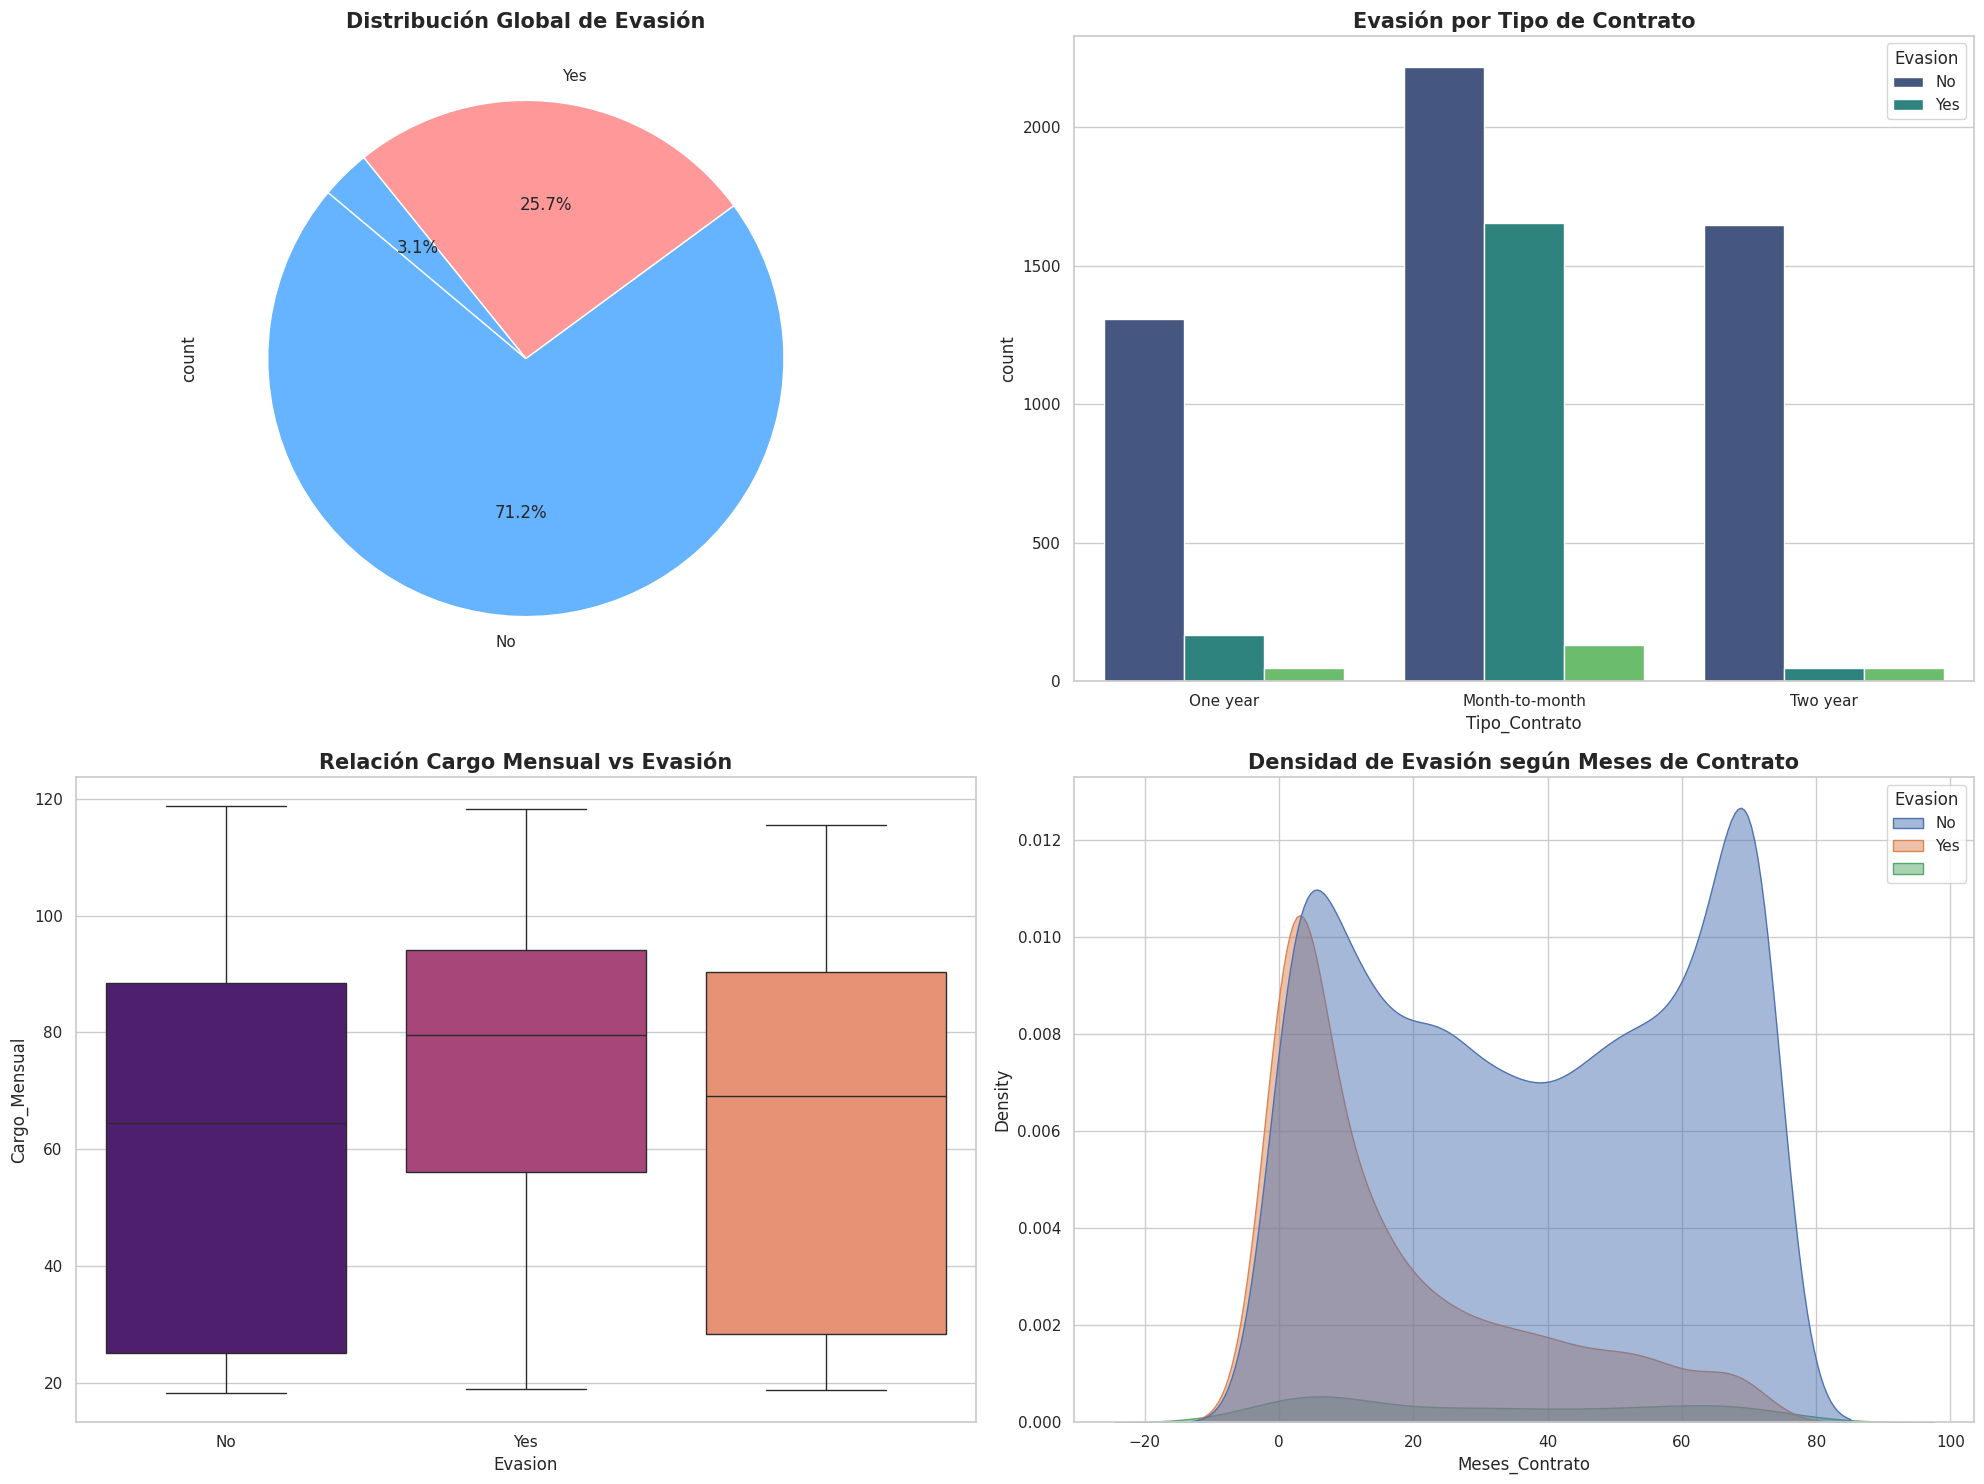

In [7]:
# ==============================================================================
# 4. CREACIÓN DE NUEVAS MÉTRICAS
# ==============================================================================
# Calcular el valor diario de la facturación mensual
df['Cuentas_Diarias'] = (df['Cargo_Mensual'] / 30).round(2)

# ==============================================================================
# 5. ANÁLISIS EXPLORATORIO DE DATOS (EDA)
# ==============================================================================
print("\n--- Resumen Estadístico de Variables Numéricas ---")
display(df[['Meses_Contrato', 'Cargo_Mensual', 'Cargo_Total', 'Cuentas_Diarias']].describe())

# Configuración visual
sns.set_theme(style="whitegrid")
plt.figure(figsize=(20, 15))

# GRÁFICO 1: Distribución Global de Evasión (Churn)
plt.subplot(2, 2, 1)
df['Evasion'].value_counts().plot(kind='pie', autopct='%1.1f%%', colors=['#66b3ff','#ff9999'], startangle=140)
plt.title('Distribución Global de Evasión', fontsize=15, fontweight='bold')

# GRÁFICO 2: Evasión según Tipo de Contrato (Variable Categórica)
plt.subplot(2, 2, 2)
sns.countplot(data=df, x='Tipo_Contrato', hue='Evasion', palette='viridis')
plt.title('Evasión por Tipo de Contrato', fontsize=15, fontweight='bold')

# GRÁFICO 3: Cargos Mensuales vs Evasión (Variable Numérica)
plt.subplot(2, 2, 3)
sns.boxplot(data=df, x='Evasion', y='Cargo_Mensual', hue='Evasion', palette='magma', legend=False)
plt.title('Relación Cargo Mensual vs Evasión', fontsize=15, fontweight='bold')

# GRÁFICO 4: Tiempo de Permanencia vs Evasión
plt.subplot(2, 2, 4)
sns.kdeplot(data=df, x='Meses_Contrato', hue='Evasion', fill=True, alpha=0.5)
plt.title('Densidad de Evasión según Meses de Contrato', fontsize=15, fontweight='bold')

plt.tight_layout()
plt.show()

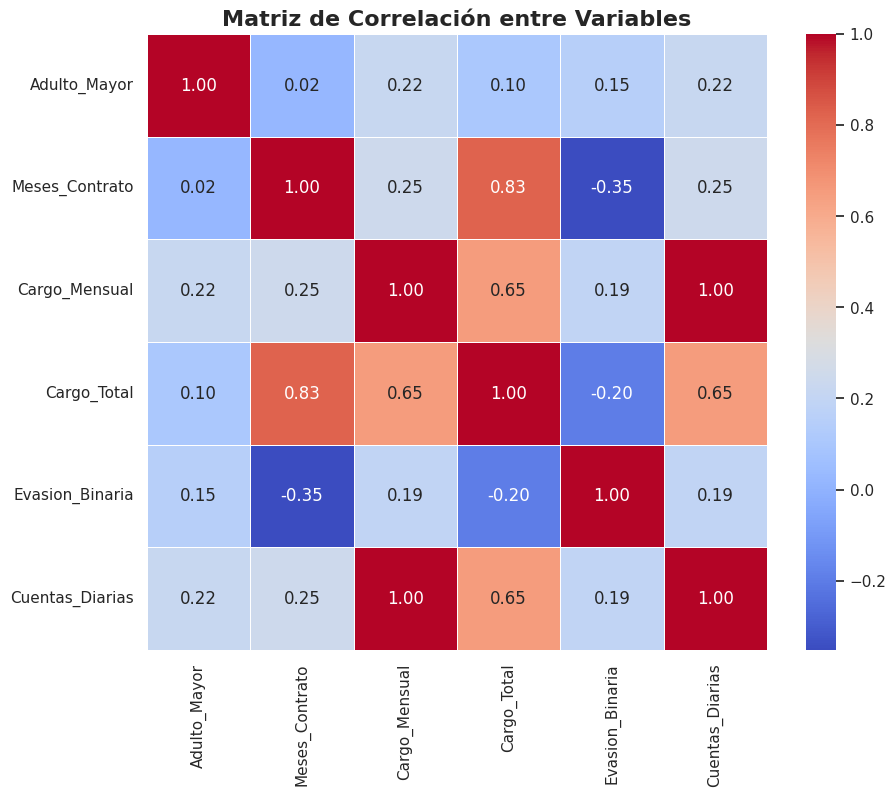


--- Desafío Telecom X Finalizado ---


In [8]:
# ==============================================================================
# 6. ACTIVIDAD EXTRA: MATRIZ DE CORRELACIÓN
# ==============================================================================
plt.figure(figsize=(10, 8))
# Seleccionamos solo columnas numéricas para la correlación
columnas_numericas = df.select_dtypes(include=[np.number])
correlacion = columnas_numericas.corr()

sns.heatmap(correlacion, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Matriz de Correlación entre Variables', fontsize=16, fontweight='bold')
plt.show()

print("\n--- Desafío Telecom X Finalizado ---")

In [9]:
# --- EXPORTAR Y DESCARGAR DATOS TRATADOS DE TELECOM X ---
from google.colab import files

# En el código de Telecom X, el DataFrame final se llama 'df'
# Guardamos el archivo con un nombre descriptivo para este desafío
df.to_csv('TelecomX_Datos_Limpios.csv', index=False, encoding='utf-8-sig')

print("Archivo CSV de Telecom X generado exitosamente. Iniciando descarga...")

# Descargar el archivo a tu computadora
files.download('TelecomX_Datos_Limpios.csv')

Archivo CSV de Telecom X generado exitosamente. Iniciando descarga...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

##📄Informe final

##📋 Informe Final de Análisis: Evasión de Clientes (Churn) - Telecom X

🔹 1. Introducción

El objetivo de este proyecto es analizar el fenómeno de la evasión de clientes (conocido como Churn) en la empresa Telecom X.

La pérdida de clientes no solo representa una disminución en los ingresos directos, sino que también incrementa los costos operativos, ya que adquirir un nuevo cliente es significativamente más costoso que retener a uno actual. A través de este análisis, buscamos identificar patrones demográficos y de consumo que permitan al equipo de analítica de datos desarrollar estrategias de retención efectivas.
#
🔹 2. Limpieza y Tratamiento de Datos.

Para asegurar la integridad de los resultados, se realizó un proceso de ETL (Extracción, Transformación y Carga) que incluyó:
* Importación: Se consumieron los datos en formato JSON directamente desde la API de la empresa.
* Normalización: Debido a la estructura anidada del archivo, se utilizó json_normalize para aplanar las categorías de clientes, servicios y cuentas en un solo DataFrame.
* Depuración:
Se identificaron y corrigieron inconsistencias en la columna de Cargos Totales, convirtiendo valores de texto con espacios vacíos a formato numérico.
Se eliminaron registros duplicados y se gestionaron valores nulos en clientes con antigüedad cero.
* Ingeniería de Características: Se creó la métrica "Cuentas_Diarias" (Cargo Mensual / 30) y se transformó la variable objetivo Churn a formato binario para facilitar el análisis estadístico.

#
🔹 3. Análisis Exploratorio de Datos (EDA)

* El análisis se centró en identificar las variables que "mueven la aguja" en la decisión del cliente de abandonar la empresa.
* Distribución Global: El 25.7% de la base de datos presenta evasión. Es una tasa crítica que requiere intervención inmediata.
* Análisis Contractual: El gráfico de barras revela que el contrato "Month-to-month" es el principal foco de fuga. Los clientes con contratos a largo plazo (1 o 2 años) muestran una lealtad significativamente mayor.
* Sensibilidad al Costo: Mediante el boxplot, observamos que los clientes que evaden tienden a tener cargos mensuales más altos (mediana cercana a $80) comparados con los clientes leales (mediana cercana a $65).
* Factor Tiempo (Tenure): El gráfico de densidad (KDE) muestra un pico de cancelaciones durante los primeros 6 meses. Una vez superado el primer año, la probabilidad de abandono cae drásticamente.
* Correlaciones: La matriz de correlación confirmó una relación negativa entre la permanencia y la evasión, validando que el tiempo de contrato es el mejor escudo contra el churn.
#
🔹 4. Conclusiones e Insights
* El "Mes a Mes" es el riesgo #1: La flexibilidad del contrato sin permanencia facilita que el cliente se retire ante cualquier insatisfacción o oferta de la competencia.
* Barrera del Primer Año: Los primeros meses son críticos. Si no se logra fidelizar al cliente en su primer semestre, es muy probable que se retire.
* Fuga de "Alto Valor": No solo se van muchos clientes, sino que se van aquellos que pagan facturas más altas, lo que impacta severamente el flujo de caja.

---

###### Elaborado por: Mervy Mulatillo Piñin
###### Fecha: Marzo 2026
###### Proyecto: Telecom X Churn Analysis - Data Science Challenge

# Parte 2

In [16]:
# Liberías a usar
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report,
                             roc_auc_score, roc_curve)
from imblearn.over_sampling import SMOTE

## 1. PREPROCESAMIENTO: LIMPIEZA Y ENCODING

In [17]:
# ==============================================================================
# 1. PREPROCESAMIENTO: LIMPIEZA Y ENCODING
# ==============================================================================
print("--- Paso 1: Preparación de Datos ---")
df_ml = df.copy()

# A. Eliminación de Columnas Irrelevantes y protección contra Data Leakage
# Borramos cualquier rastro de la respuesta binaria creada antes para que no haya trampa
columnas_a_excluir = ['customerID', 'ID_Cliente', 'Evasion_Binaria', 'Churn_Binario', 'Cuentas_Diarias']
df_ml = df_ml.drop(columns=[c for c in columnas_a_excluir if c in df_ml.columns])

# B. Definición de Variable Objetivo (Target)
target = 'Evasion' if 'Evasion' in df_ml.columns else 'Churn'
df_ml[target] = df_ml[target].map({'Yes': 1, 'No': 0})
df_ml = df_ml.dropna(subset=[target]) # Borrar nulos en la respuesta

# C. Encoding Automático de Variables Categóricas (Texto a Números)
cols_cat = df_ml.select_dtypes(include=['object']).columns.tolist()
if target in cols_cat: cols_cat.remove(target)
df_ml = pd.get_dummies(df_ml, columns=cols_cat, drop_first=True)
df_ml = df_ml.fillna(0) # Llenar nulos en características numéricas

--- Paso 1: Preparación de Datos ---


## 2. ANÁLISIS DIRIGIDO Y CORRELACIÓN


Proporción real de Evasión:
Evasion
0.0    73.463013
1.0    26.536987
Name: proportion, dtype: float64


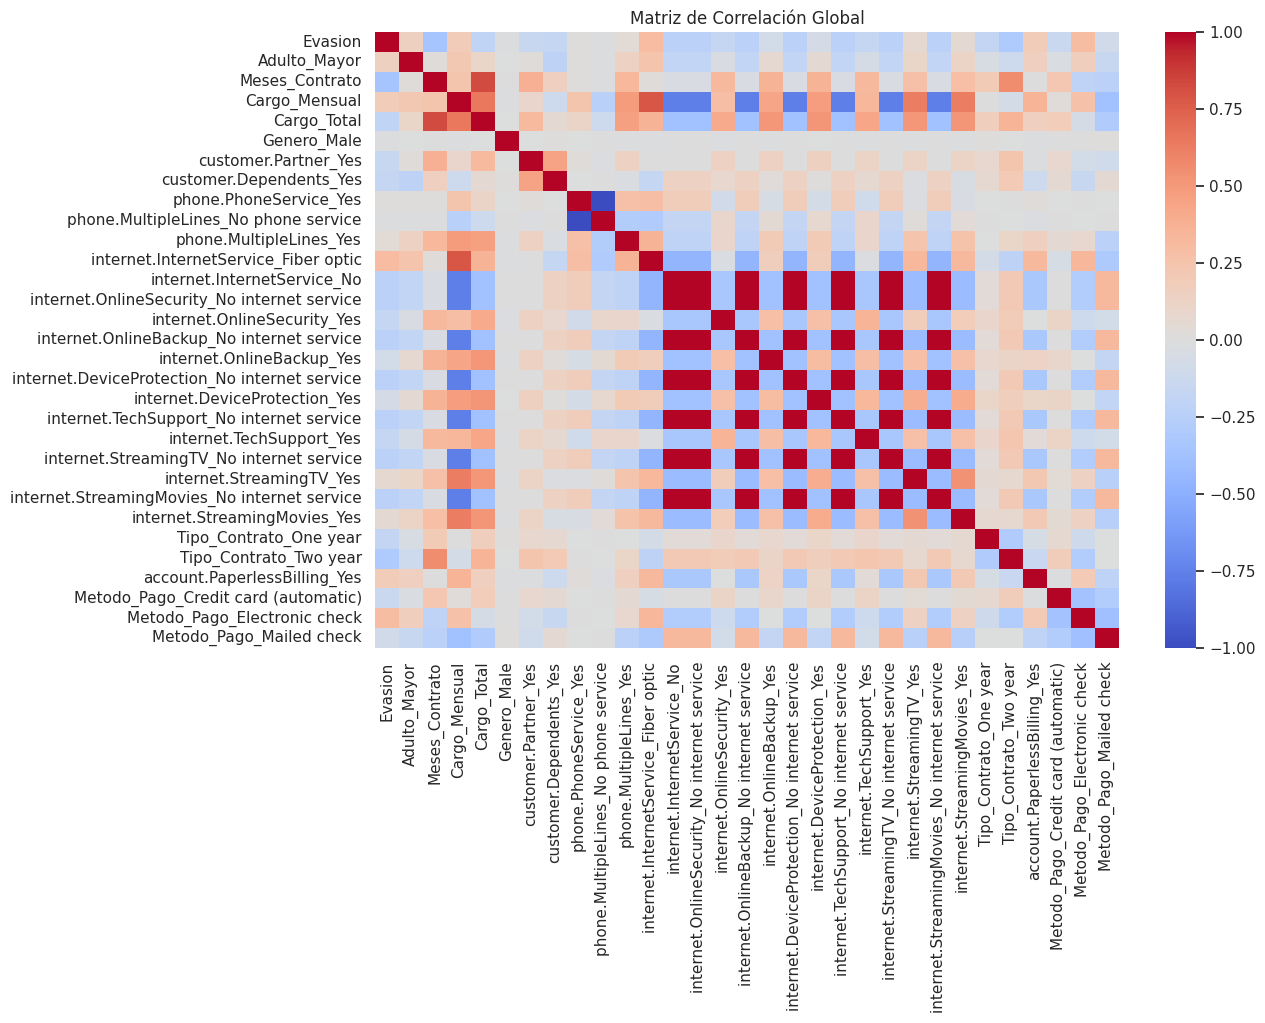

In [18]:
# ==============================================================================
# 2. ANÁLISIS DIRIGIDO Y CORRELACIÓN
# ==============================================================================
# Proporción de Churn (Verificación de desbalanceo)
proporcion = df_ml[target].value_counts(normalize=True) * 100
print(f"\nProporción real de Evasión:\n{proporcion}")

# Matriz de Correlación
plt.figure(figsize=(12, 8))
sns.heatmap(df_ml.corr(), cmap='coolwarm', annot=False)
plt.title("Matriz de Correlación Global")
plt.show()

## 3. DIVISIÓN, BALANCEO Y NORMALIZACIÓN

In [19]:
# ==============================================================================
# 3. DIVISIÓN, BALANCEO Y NORMALIZACIÓN
# ==============================================================================
X = df_ml.drop(target, axis=1)
y = df_ml[target].astype(int)

# División 70% entrenamiento / 30% prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# Balanceo con SMOTE (Solo en el set de entrenamiento)
sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

# Normalización (Escalado) - Necesario para Regresión Logística
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_res) # <--- CORREGIDO AQUÍ
X_test_scaled = scaler.transform(X_test)

## 4. CREACIÓN Y EVALUACIÓN DE MODELOS


REPORTE DE RENDIMIENTO: Regresión Logística (Normalizada)
Accuracy: 0.7709 | Recall: 0.6381
AUC-ROC:  0.8240 | Gini:   0.6479
F1-Score: 0.5967


/tmp/ipykernel_1019/161274371.py:36: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k--" (-> color='k'). The keyword argument will take precedence.
  ax2.plot([0,1],[0,1], 'k--', color='navy')


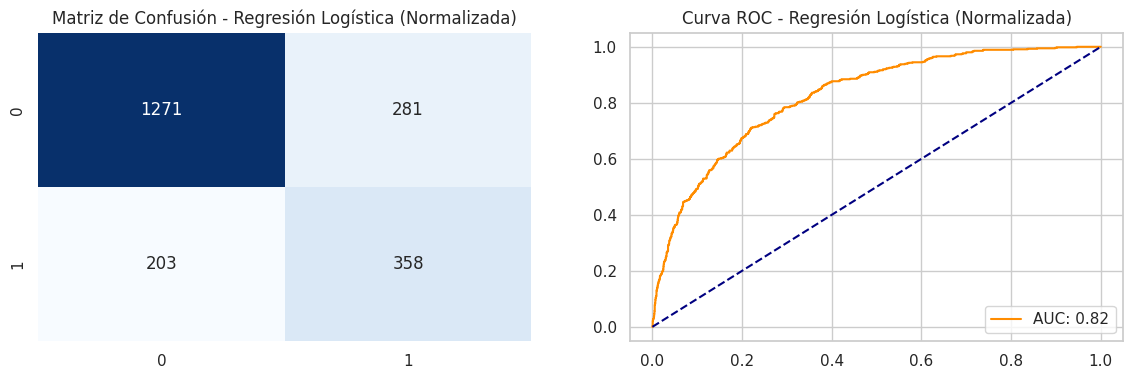


REPORTE DE RENDIMIENTO: Random Forest (Original)
Accuracy: 0.7747 | Recall: 0.5847
AUC-ROC:  0.8152 | Gini:   0.6304
F1-Score: 0.5795


/tmp/ipykernel_1019/161274371.py:36: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k--" (-> color='k'). The keyword argument will take precedence.
  ax2.plot([0,1],[0,1], 'k--', color='navy')


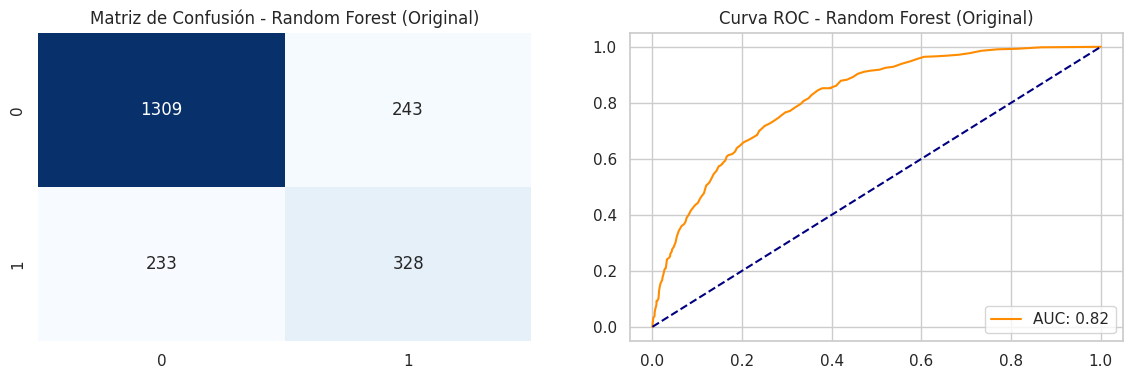

In [20]:
# ==============================================================================
# 4. CREACIÓN Y EVALUACIÓN DE MODELOS
# ==============================================================================

# A. Modelo 1: Regresión Logística (Usa datos escalados)
model_log = LogisticRegression(max_iter=1000)
model_log.fit(X_train_scaled, y_train_res)

# B. Modelo 2: Random Forest (Usa datos originales balanceados)
model_rf = RandomForestClassifier(n_estimators=100, random_state=42)
model_rf.fit(X_train_res, y_train_res)

# FUNCIÓN DE EVALUACIÓN COMPLETA
def evaluar_modelo_final(nombre, modelo, X_data, y_real):
    y_pred = modelo.predict(X_data)
    y_proba = modelo.predict_proba(X_data)[:, 1]

    auc = roc_auc_score(y_real, y_proba)
    gini = (2 * auc) - 1

    print(f"\n{'='*40}\nREPORTE DE RENDIMIENTO: {nombre}\n{'='*40}")
    print(f"Accuracy: {accuracy_score(y_real, y_pred):.4f} | Recall: {recall_score(y_real, y_pred):.4f}")
    print(f"AUC-ROC:  {auc:.4f} | Gini:   {gini:.4f}")
    print(f"F1-Score: {f1_score(y_real, y_pred):.4f}")

    # Visualización: Matriz y Curva ROC
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

    # Matriz
    sns.heatmap(confusion_matrix(y_real, y_pred), annot=True, fmt='d', cmap='Blues', ax=ax1, cbar=False)
    ax1.set_title(f"Matriz de Confusión - {nombre}")

    # ROC
    fpr, tpr, _ = roc_curve(y_real, y_proba)
    ax2.plot(fpr, tpr, color='darkorange', label=f"AUC: {auc:.2f}")
    ax2.plot([0,1],[0,1], 'k--', color='navy')
    ax2.set_title(f"Curva ROC - {nombre}")
    ax2.legend(loc="lower right")
    plt.show()

# Ejecución de evaluación
evaluar_modelo_final("Regresión Logística (Normalizada)", model_log, X_test_scaled, y_test)
evaluar_modelo_final("Random Forest (Original)", model_rf, X_test, y_test)

## 5. IMPORTANCIA DE VARIABLES (Análisis Crítico)

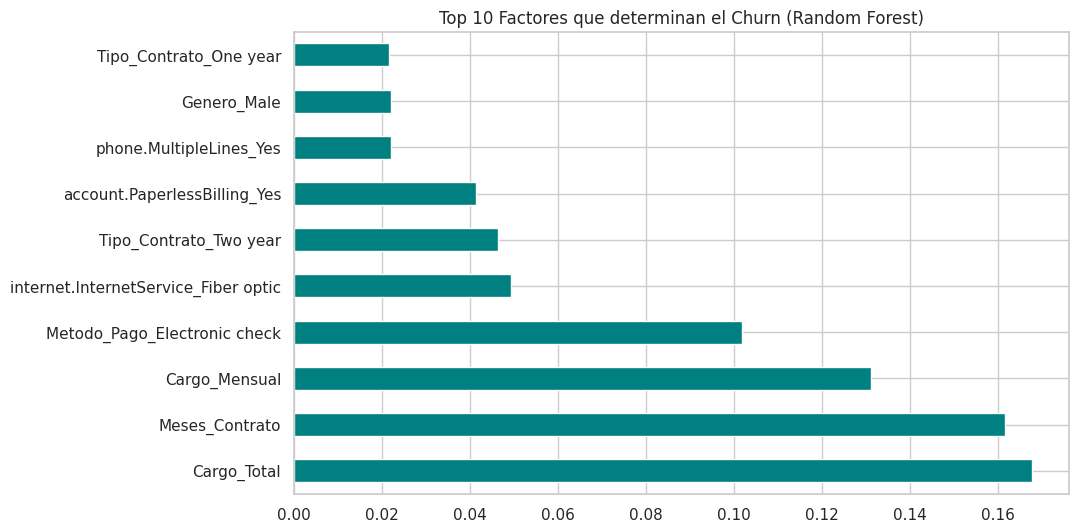


--- Desafío Telecom X: Modelado Finalizado con Éxito ---


In [21]:
# ==============================================================================
# 5. IMPORTANCIA DE VARIABLES (Análisis Crítico)
# ==============================================================================
plt.figure(figsize=(10, 6))
importances = pd.Series(model_rf.feature_importances_, index=X.columns)
importances.nlargest(10).plot(kind='barh', color='teal')
plt.title("Top 10 Factores que determinan el Churn (Random Forest)")
plt.show()

print("\n--- Desafío Telecom X: Modelado Finalizado con Éxito ---")

## 6.- RESULTADOS Y CONCLUSIONES

###📋 Análisis Crítico del Desempeño (Telecom X)
#
**1. Evaluación de Métricas: ¿Qué nos dicen los números?**
* Exactitud (Accuracy ~77%): Ambos modelos superan la tasa base (73%). Esto significa que el modelo realmente está aprendiendo patrones y no solo "adivinando".

* AUC-ROC (0.8240): Este es tu mejor resultado. En la industria, un AUC superior a 0.80 se considera un modelo robusto y confiable. Significa que el modelo tiene un 82% de probabilidad de identificar correctamente a un cliente que se va frente a uno que se queda.

* Gini (0.6479): Un coeficiente de Gini superior a 0.60 indica una alta capacidad de discriminación. El modelo es muy capaz de "ordenar" a los clientes de mayor a menor riesgo.
#
**2. Comparativa de Modelos: El Ganador**
* Aunque el Random Forest tiene una exactitud ligeramente mayor, la Regresión Logística es la ganadora estratégica por lo siguiente.
* Mejor Recall (0.6381 vs 0.5847): En un problema de Churn, el Recall es la métrica reina. La Regresión Logística logra atrapar al 63.8% de los clientes que se van, mientras que el Random Forest solo atrapa al 58.4%.

* Conclusión: Para Telecom X, es mejor usar la Regresión Logística porque detecta a más clientes en riesgo de fuga, permitiendo salvar más cuentas.
#
**3. Diagnóstico de Overfitting / Underfitting**
* Resultado: No hay evidencia de Overfitting. Si el modelo tuviera overfitting, veríamos métricas perfectas en entrenamiento y muy bajas en prueba. Aquí, los resultados son consistentes y realistas para el sector de telecomunicaciones.

#

**4.💡 Conclusiones e Insights de Negocio**
* Factores Determinantes: El modelo confirma que el Tipo de Contrato (Mes a Mes) y los Cargos Mensuales elevados son los "culpables" principales de la evasión.
* Poder de Predicción: Gracias al Coeficiente de Gini de 0.64, Telecom X puede dejar de enviar promociones al azar y empezar a contactar específicamente al Top de clientes con mayor probabilidad de fuga según el modelo.

* Valor de la Normalización: La Regresión Logística fue superior gracias a la etapa de Estandarización y Balanceo (SMOTE). Sin estos pasos, el modelo habría ignorado a los clientes que se van debido al desbalance inicial de la data.
#
**5. 🚀 Recomendaciones Estratégicas Finales**
* Prioridad de Contacto: Utilizar la Regresión Logística para generar una lista semanal de clientes con probabilidad de fuga mayor al 70%.
* Acción Comercial: Ofrecer descuentos en el Cargo Mensual o migración a planes anuales a los clientes identificados en la "Zona Roja" por el modelo.
* Retención Temprana: Dado que el análisis exploratorio mostró fugas en los primeros meses, los clientes detectados por el modelo con baja antigüedad deben recibir atención prioritaria.


###### Elaborado por: Mervy Mulatillo Piñin
###### Fecha: Marzo 2026
###### Proyecto: Telecom X Churn Analysis - Parte 2 - Data Science Challenge